dt = 0.001
nt = 1000
Animation saved as heat_hat_diffusion.mp4


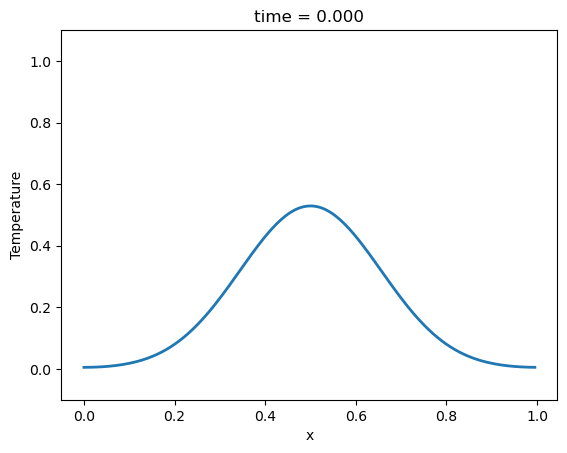

In [2]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# --------------------------------------------------
# Grid
# --------------------------------------------------

nx = 200
xmin = 0.0
xmax = 1.0

x = np.linspace(xmin, xmax, nx, endpoint=False)
dx = (xmax-xmin)/nx

# --------------------------------------------------
# Diffusion number
# --------------------------------------------------

Fo = 0.4          # diffusion number

alpha = 0.01

dt = Fo*dx**2/alpha

tmax = 1.0
nt = int(tmax/dt)

print("dt =",dt)
print("nt =",nt)

# --------------------------------------------------
# Flat hat initial condition
# --------------------------------------------------

u = np.zeros(nx)

for i in range(nx):

    if 0.4 <= x[i] <= 0.6:
        u[i] = 1.0

# --------------------------------------------------
# Laplacian (2nd order)
# --------------------------------------------------

def laplacian(u):

    return (np.roll(u,-1) - 2*u + np.roll(u,1)) / dx**2


# --------------------------------------------------
# Time step (explicit)
# --------------------------------------------------

def step(u):

    return u + Fo*(np.roll(u,-1) - 2*u + np.roll(u,1))


# --------------------------------------------------
# Plot setup
# --------------------------------------------------

fig,ax = plt.subplots()

line, = ax.plot(x,u,lw=2)

ax.set_ylim(-0.1,1.1)
ax.set_xlabel("x")
ax.set_ylabel("Temperature")

# --------------------------------------------------
# Animation update
# --------------------------------------------------

def update(frame):

    global u

    for _ in range(5):
        u = step(u)

    line.set_ydata(u)

    ax.set_title(f"time = {frame*5*dt:.3f}")

    return line,

# --------------------------------------------------
# Animation
# --------------------------------------------------

frames = nt//5

anim = FuncAnimation(fig, update, frames=frames)

writer = FFMpegWriter(fps=30)

anim.save("heat_hat_diffusion.mp4", writer=writer)

print("Animation saved as heat_hat_diffusion.mp4")